<a href="https://colab.research.google.com/github/hyun0609kr-spec/henry/blob/claude%2Fadd-claude-documentation-Uz0eS/ETF_%ED%8F%89%EA%B7%A0%ED%9A%8C%EA%B7%80_3%EA%B7%B8%EB%A3%B9_%EB%A6%AC%EB%B9%84%EC%A0%84.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# -*- coding: utf-8 -*-

# ── 1. 임포트 ────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import datetime
import warnings
import time
import os
import importlib

from statsmodels.tsa.stattools import adfuller
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

warnings.filterwarnings('ignore')

# ── 2. 한글 폰트 설정 ────────────────────────────────────────
def setup_korean_font():
    nanum_candidates = [
        '/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
        '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf',
    ]
    font_found = False
    for path in nanum_candidates:
        if os.path.exists(path):
            fm.fontManager.addfont(path)
            font_name = fm.FontProperties(fname=path).get_name()
            matplotlib.rcParams['font.family'] = font_name
            font_found = True
            print(f"   ✅ 한글 폰트 적용: {font_name}")
            break

    if not font_found:
        try:
            importlib.reload(fm)
        except Exception:
            pass
        print("   ⚠️ NanumGothic 없음 → 한글 깨짐 가능")
        print("     셀 상단에서 실행: !apt-get install -y fonts-nanum")

    matplotlib.rcParams['axes.unicode_minus'] = False


# ── 3. 수학적 지표 계산 함수 모음 ──────────────────────────────
def hurst_rs(series: np.ndarray) -> float:
    n = len(series)
    if n < 50:
        return np.nan

    raw_lags = sorted(set([
        max(10, n // 32), max(10, n // 16),
        max(10, n // 10), max(10, n // 8),
        max(10, n // 5),  max(10, n // 4),
        max(10, n // 3),  max(10, n // 2),
    ]))

    log_lags, log_rs = [], []

    for lag in raw_lags:
        if lag < 10 or lag > n:
            continue
        rs_list = []
        for start in range(0, n - lag + 1, lag):
            sub = series[start:start + lag]
            if len(sub) < lag:
                continue
            mean    = np.mean(sub)
            deviate = np.cumsum(sub - mean)
            r       = np.max(deviate) - np.min(deviate)
            s       = np.std(sub, ddof=1)
            if s > 0:
                rs_list.append(r / s)
        if len(rs_list) == 0:
            continue
        log_lags.append(np.log(lag))
        log_rs.append(np.log(np.mean(rs_list)))

    if len(log_lags) < 3:
        return np.nan

    coeffs = np.polyfit(log_lags, log_rs, 1)
    return round(float(coeffs[0]), 4)

def calc_halflife_acf(series: pd.Series) -> float:
    try:
        from statsmodels.tsa.stattools import acf as _acf
        log_ret = np.log(series / series.shift(1)).dropna()
        if len(log_ret) < 30:
            return np.nan
        rho1 = _acf(log_ret, nlags=1, fft=True)[1]
        if rho1 > -0.05:
            return np.inf
        return round(-np.log(2) / np.log(abs(rho1)), 1)
    except Exception:
        return np.nan

def calc_variance_ratio(series: pd.Series, q: int = 5) -> float:
    try:
        log_ret = np.log(series / series.shift(1)).dropna().values
        if len(log_ret) < q * 10:
            return np.nan
        var1 = np.var(log_ret, ddof=1)
        if var1 == 0:
            return np.nan
        q_ret = np.array([
            np.sum(log_ret[i:i+q]) for i in range(len(log_ret) - q + 1)
        ])
        varq = np.var(q_ret, ddof=1)
        vr = varq / (q * var1)
        return round(float(vr), 4)
    except Exception:
        return np.nan

def calc_hurst(series: pd.Series) -> float:
    log_returns = np.log(series / series.shift(1)).dropna()
    if len(log_returns) < 50:
        return np.nan
    return hurst_rs(log_returns.values)

def calc_adf(series: pd.Series) -> tuple:
    try:
        res   = adfuller(series, autolag='AIC')
        stat  = round(float(res[0]), 4)
        pval  = round(float(res[1]), 4)
        return stat, pval, pval < CONFIG['adf_pvalue']
    except Exception:
        return np.nan, np.nan, False

def calc_halflife(series: pd.Series) -> float:
    try:
        y     = series.values.astype(float)
        y_lag = y[:-1]
        y_dif = np.diff(y)
        X     = add_constant(y_lag)
        lam   = float(OLS(y_dif, X).fit().params[1])
        if lam >= 0:
            return np.inf
        return round(-np.log(2) / lam, 1)
    except Exception:
        return np.nan

def calc_bollinger(series: pd.Series) -> dict:
    try:
        n   = CONFIG['bb_period']
        k   = CONFIG['bb_std']
        ma  = series.rolling(n).mean()
        std = series.rolling(n).std()
        up  = ma + k * std
        lo  = ma - k * std
        pct = (series - lo) / (up - lo)
        return {
            'current'   : round(float(series.iloc[-1]), 0),
            'ma'        : round(float(ma.iloc[-1]),  0),
            'upper'     : round(float(up.iloc[-1]),  0),
            'lower'     : round(float(lo.iloc[-1]),  0),
            'pct_b'     : round(float(pct.iloc[-1]), 4),
            'band_width': round(float((up.iloc[-1] - lo.iloc[-1]) / ma.iloc[-1] * 100), 2),
        }
    except Exception:
        return {}


# ── 4. 설정값 및 데이터 로드 ───────────────────────────────────
CONFIG = {
    'start_date'    : '20230101',
    'end_date'      : datetime.date.today().strftime('%Y%m%d'),
    'bb_period'     : 80,
    'bb_std'        : 2,
    'hurst_threshold': 0.55,
    'adf_pvalue'    : 0.05,
    'halflife_max'  : 120,
    'min_bars'      : 120,
    'api_delay'     : 0.3,
    'excel_path'    : 'ETFs_list.xlsx',
}

def load_etf_universe(filepath: str) -> pd.DataFrame:
    df   = pd.read_excel(filepath, dtype={'종목코드': str})
    mask = df['종목코드'].str.match(r'^\d{6}$', na=False)
    valid = df[mask].copy().reset_index(drop=True)
    print(f"📂 유니버스 로드: 전체 {len(df)}개 → 유효 {len(valid)}개 (제외 {len(df)-len(valid)}개)")
    return valid

def fetch_price_series(ticker: str, start: str, end: str, min_bars: int = 120) -> pd.Series:
    try:
        import FinanceDataReader as fdr
    except ImportError:
        print("⚠️ FinanceDataReader가 설치되지 않았습니다. '!pip install finance-datareader'를 실행하세요.")
        return None

    try:
        df = fdr.DataReader(ticker, start, end)
        if df is None or df.empty:
            return None
        if 'Close' in df.columns:
            s = df['Close'].dropna()
            if len(s) >= min_bars:
                return s
        return None
    except Exception:
        return None


# ── 5. 교차검증 및 분류 엔진 ───────────────────────────────────
def cross_validate(hurst: float, hl_ols: float, hl_acf: float, vr: float, adf_pval: float) -> tuple:
    signals = {}
    if not pd.isna(hurst): signals['H'] = hurst < 0.50

    hl_ols_v = hl_ols if (hl_ols != 9999 and not pd.isna(hl_ols)) else np.inf
    if not np.isinf(hl_ols_v) and not pd.isna(hl_ols_v):
        signals['HL_OLS'] = hl_ols_v <= CONFIG['halflife_max']
    else: signals['HL_OLS'] = False

    if not pd.isna(hl_acf) and not np.isinf(hl_acf):
        signals['HL_ACF'] = hl_acf <= CONFIG['halflife_max']
    else: signals['HL_ACF'] = False

    if not pd.isna(vr): signals['VR'] = vr < 1.0
    if not pd.isna(adf_pval): signals['ADF'] = adf_pval < 0.10

    agree_count = sum(signals.values())
    total       = len(signals)

    if total == 0: return 0, 'N/A', '데이터부족'
    ratio = agree_count / total

    hl_diverge = ''
    if (not pd.isna(hl_acf) and not np.isinf(hl_acf) and not pd.isna(hl_ols_v) and not np.isinf(hl_ols_v)):
        ratio_hl = hl_ols_v / max(hl_acf, 1)
        if ratio_hl > 3 or ratio_hl < 0.33:
            hl_diverge = f' ⚠️HL괴리({hl_ols_v:.0f}vs{hl_acf:.0f})'

    if ratio >= 0.8: grade = '🟢HIGH'
    elif ratio >= 0.6: grade = '🟡MED'
    else: grade = '🔴LOW'

    detail = (f"{agree_count}/{total}일치"
              f"[H={'✓' if signals.get('H') else '✗'}"
              f"|OLS={'✓' if signals.get('HL_OLS') else '✗'}"
              f"|ACF={'✓' if signals.get('HL_ACF') else '✗'}"
              f"|VR={'✓' if signals.get('VR') else '✗'}"
              f"|ADF={'✓' if signals.get('ADF') else '✗'}]"
              f"{hl_diverge}")
    return agree_count, grade, detail

def classify_etf(hurst: float, pval: float, hl) -> tuple:
    if pd.isna(hurst) or pd.isna(pval):
        return 0, '⬜ 미분류', 'NaN'

    score, reasons = 0, []
    if hurst < 0.45:   score += 3; reasons.append(f'H={hurst:.3f}(강회귀)')
    elif hurst < 0.55: score += 2; reasons.append(f'H={hurst:.3f}(회귀)')
    elif hurst < 0.65: score += 1; reasons.append(f'H={hurst:.3f}(경계)')
    else:              score += 0; reasons.append(f'H={hurst:.3f}(추세)')

    if pval < 0.01:    score += 3; reasons.append(f'p={pval:.3f}(강정상)')
    elif pval < 0.05:  score += 2; reasons.append(f'p={pval:.3f}(정상)')
    elif pval < 0.10:  score += 1; reasons.append(f'p={pval:.3f}(약정상)')
    else:              score += 0; reasons.append(f'p={pval:.3f}(비정상)')

    hl_num = hl if (hl != np.inf and not pd.isna(hl)) else 99999
    if hl_num == 99999:                       score += 0; reasons.append('HL=∞')
    elif hl_num <= CONFIG['bb_period']:       score += 3; reasons.append(f'HL={hl_num:.0f}d(BB내)')
    elif hl_num <= CONFIG['halflife_max']:    score += 2; reasons.append(f'HL={hl_num:.0f}d(허용)')
    elif hl_num <= 200:                       score += 1; reasons.append(f'HL={hl_num:.0f}d(느림)')
    else:                                     score += 0; reasons.append(f'HL={hl_num:.0f}d(매우느림)')

    reason_str = ' | '.join(reasons)
    if score >= 6: return 1, '✅ 1그룹', reason_str
    elif score >= 3: return 2, '⚠️ 2그룹', reason_str
    else:            return 3, '❌ 3그룹', reason_str


# ── 6. 스크리닝 실행 모듈 ─────────────────────────────────────
def _process_one(row: pd.Series) -> dict:
    ticker = str(row['종목코드']).zfill(6)
    name   = row['종목명']

    series = fetch_price_series(ticker, CONFIG['start_date'], CONFIG['end_date'], CONFIG['min_bars'])

    empty = dict(ETF명=name, 종목코드=ticker,
                 **{k: np.nan for k in ['Hurst(H)','ADF_p값','HalfLife(일)',
                                        'HL_ACF(일)','VR비율','%B','현재가',
                                        'BB중심선','BB하단','BB상단','밴드폭(%)']},
                 ADF_정상성='-', BB이탈='', 등급='⬜ 미분류',
                 그룹=0, 판정근거='데이터없음', 교차검증='N/A', CV_등급='N/A', 데이터봉수=0)

    if series is None:
        return empty

    H               = calc_hurst(series)
    _, pval, is_st  = calc_adf(series)
    hl              = calc_halflife(series)
    hl_acf          = calc_halflife_acf(series)
    vr              = calc_variance_ratio(series)
    bb              = calc_bollinger(series)
    gnum, grade, why = classify_etf(H, pval, hl)

    pct_b   = bb.get('pct_b', np.nan)
    hl_save = 9999 if hl == np.inf else (np.nan if pd.isna(hl) else hl)
    hl_acf_save = (np.nan if (pd.isna(hl_acf) or hl_acf == np.inf) else round(hl_acf, 1))

    if not pd.isna(pct_b):
        bb_flag = '🔴 하단이탈' if pct_b < 0 else ('🔵 상단이탈' if pct_b > 1 else '')
    else:
        bb_flag = ''

    cv_count, cv_grade, cv_detail = cross_validate(H, hl_save, hl_acf_save, vr, pval)

    return dict(
        ETF명=name, 종목코드=ticker,
        **{'Hurst(H)' : H,
           'ADF_p값'  : pval,
           'ADF_정상성': '✅' if is_st else '❌',
           'HalfLife(일)' : hl_save,
           'HL_ACF(일)'   : hl_acf_save,
           'VR비율'        : vr,
           '%B'      : pct_b,
           '현재가'  : bb.get('current', np.nan),
           'BB중심선': bb.get('ma',      np.nan),
           'BB하단'  : bb.get('lower',   np.nan),
           'BB상단'  : bb.get('upper',   np.nan),
           '밴드폭(%)': bb.get('band_width', np.nan),
           'BB이탈'  : bb_flag,
           '등급'    : grade,
           '그룹'    : gnum,
           '판정근거': why,
           '교차검증' : cv_detail,
           'CV_등급'  : cv_grade,
           '데이터봉수': len(series)},
    )

def run_screening(etf_df: pd.DataFrame) -> pd.DataFrame:
    total   = len(etf_df)
    results = []
    print(f"\n🔍 스크리닝 시작: {total}개 ETF")
    print(f"   기간: {CONFIG['start_date']} ~ {CONFIG['end_date']}\n")

    for seq, (_, row) in enumerate(etf_df.iterrows(), start=1):
        if seq % 10 == 0 or seq == 1:
            print(f"   [{seq:>4}/{total}]  {row['종목명'][:20]}")
        results.append(_process_one(row))
        time.sleep(CONFIG['api_delay'])

        if seq % 100 == 0:
            pd.DataFrame(results).to_csv('checkpoint.csv', index=False, encoding='utf-8-sig')
            print(f"   💾 체크포인트 저장 ({seq}개)")

    df = (pd.DataFrame(results).sort_values(['그룹', 'Hurst(H)']).reset_index(drop=True))
    print(f"\n✅ 완료: {total}개 처리")
    return df

def run_quick(etf_df: pd.DataFrame, n: int = 50) -> pd.DataFrame:
    keywords = ['반도체','자동차','에너지화학','건설','운송',
                '화장품','여행레저','필수소비재','바이오','게임',
                '2차전지','소프트웨어','S&P500','나스닥','골드','원유']
    mask     = etf_df['종목명'].str.contains('|'.join(keywords), na=False)
    pri      = etf_df[mask].head(n // 2)
    rnd_pool = etf_df[~mask]
    rnd_n    = min(n - len(pri), len(rnd_pool))
    rnd      = rnd_pool.sample(rnd_n, random_state=42) if rnd_n > 0 else pd.DataFrame()
    sample   = (pd.concat([pri, rnd]).drop_duplicates().reset_index(drop=True))
    print(f"🚀 빠른 모드: {len(sample)}개 (키워드 {len(pri)}개 + 랜덤 {len(rnd)}개)")
    return run_screening(sample)


# ── 7. 출력 및 시각화 ─────────────────────────────────────────
def plot_results(df: pd.DataFrame, top_n: int = 40):
    colors = {1:'#2ecc71', 2:'#f39c12', 3:'#e74c3c', 0:'#bdc3c7'}
    labels = {1:'1그룹(적합)', 2:'2그룹(주의)', 3:'3그룹(부적합)', 0:'미분류'}

    valid = df[df['그룹'] > 0].copy()
    g1    = df[df['그룹'] == 1].copy()

    fig = plt.figure(figsize=(20, 16))
    fig.suptitle('ETF 평균회귀 스크리닝 결과\nBB[80,2] + Hurst + ADF + Half-Life', fontsize=15, fontweight='bold', y=0.98)

    ax1 = fig.add_subplot(2, 2, 1)
    for g in [3, 2, 1]:
        sub = valid[valid['그룹'] == g].dropna(subset=['Hurst(H)', 'HalfLife(일)'])
        hl  = sub['HalfLife(일)'].replace(9999, 300).clip(upper=300)
        ax1.scatter(sub['Hurst(H)'], hl, c=colors[g], label=labels[g], s=55, alpha=0.75, zorder=3)

    ax1.axvline(0.50,  color='navy',   ls='--', lw=1.2, alpha=0.6, label='H=0.5 랜덤워크')
    ax1.axvline(0.55,  color='orange', ls='--', lw=1.2, alpha=0.6, label='H=0.55 임계')
    ax1.axhline(CONFIG['bb_period'],  color='#27ae60', ls='--', lw=1.2, alpha=0.6, label=f'HL={CONFIG["bb_period"]}d (BB기간)')
    ax1.axhline(CONFIG['halflife_max'], color='#c0392b', ls='--', lw=1.2, alpha=0.6, label=f'HL={CONFIG["halflife_max"]}d (최대허용)')

    ax1.set_xlabel('Hurst Exponent (H)', fontsize=11)
    ax1.set_ylabel('Half-Life (거래일, 300+클리핑)', fontsize=11)
    ax1.set_title('① Hurst vs Half-Life 산점도', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=8)
    ax1.grid(alpha=0.3)
    ax1.set_xlim(0.2, 0.9)
    ax1.set_ylim(-5, 310)

    ax2 = fig.add_subplot(2, 2, 2)
    gcounts = df['그룹'].value_counts().sort_index()
    glabels = [f"{labels.get(g,'미분류')}\n({c}개)" for g, c in gcounts.items()]
    ax2.pie(gcounts.values, labels=glabels, colors=[colors.get(g,'#bdc3c7') for g in gcounts.index], autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10})
    ax2.set_title('② 그룹별 분포', fontsize=12, fontweight='bold')

    ax3 = fig.add_subplot(2, 1, 2)
    if len(g1) > 0:
        g1s = g1.dropna(subset=['%B']).sort_values('%B').head(top_n)
        bcolors = ['#e74c3c' if v < 0 else '#3498db' if v > 1 else '#2ecc71' for v in g1s['%B']]
        ax3.barh(range(len(g1s)), g1s['%B'], color=bcolors, alpha=0.85, height=0.72)
        ax3.set_yticks(range(len(g1s)))
        ax3.set_yticklabels(g1s['ETF명'], fontsize=8)

        ax3.axvline(0,   color='#e74c3c', ls='--', lw=2, alpha=0.9, label='하단밴드 (매수신호 기준)')
        ax3.axvline(0.5, color='gray',    ls='-',  lw=1, alpha=0.35)
        ax3.axvline(1,   color='#3498db', ls='--', lw=2, alpha=0.9, label='상단밴드 (매도신호 기준)')

        for i, (_, r) in enumerate(g1s.iterrows()):
            if r['%B'] < 0:
                ax3.text(r['%B'] - 0.01, i, f" {r['%B']:.2f}", va='center', fontsize=8, color='#c0392b', fontweight='bold')

        ax3.set_xlabel('%B  (볼린저밴드 상대 위치)', fontsize=11)
        ax3.set_title('③ 1그룹 ETF — BB[80,2] 현재 위치 (%B)\n빨간 (%B<0): 하단이탈 매수신호  |  파란 (%B>1): 상단이탈 매도신호', fontsize=12, fontweight='bold')
        ax3.legend(fontsize=9, loc='lower right')
        ax3.grid(alpha=0.25, axis='x')
        ax3.set_xlim(-0.6, 1.6)
    else:
        ax3.text(0.5, 0.5, '1그룹 ETF 없음', ha='center', va='center', fontsize=14, transform=ax3.transAxes)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig('etf_screening_result.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print("📊 차트 저장: etf_screening_result.png")

def print_report(df: pd.DataFrame):
    today = datetime.date.today().strftime('%Y-%m-%d')
    SEP = "=" * 68
    print(f"\n{SEP}")
    print(f"  📋 ETF 평균회귀 스크리닝 리포트  —  {today}")
    print(f"  BB[{CONFIG['bb_period']},{CONFIG['bb_std']}] | Hurst<{CONFIG['hurst_threshold']} | ADF_p<{CONFIG['adf_pvalue']} | HL≤{CONFIG['halflife_max']}일")
    print(SEP)

    for gnum, gname in [(1,'✅ 1그룹 — 평균회귀 적합'), (2,'⚠️  2그룹 — 조건부 (모니터링)'), (3,'❌  3그룹 — 부적합'), (0,'⬜  미분류')]:
        sub = df[df['그룹'] == gnum]
        if sub.empty: continue
        print(f"\n{gname}  ({len(sub)}종목)")
        print("-" * 68)
        for _, r in sub.iterrows():
            hl   = r['HalfLife(일)']
            hls  = '∞' if hl == 9999 else ('N/A' if pd.isna(hl) else f"{hl:.0f}d")
            H    = r['Hurst(H)']
            Hs   = f"{H:.3f}" if not pd.isna(H) else 'N/A'
            p    = r['ADF_p값']
            ps   = f"{p:.3f}" if not pd.isna(p) else 'N/A'
            pct  = r['%B']
            pcts = f"{pct:+.2f}" if not pd.isna(pct) else 'N/A'
            flag = r.get('BB이탈', '')
            print(f"  {r['종목코드']}  {str(r['ETF명'])[:17]:<17}  H={Hs}  p={ps}  HL={hls:<5}  %B={pcts}  {flag}")

    buy = df[(df['그룹'] == 1) & (df['%B'].notna()) & (df['%B'] < 0)]
    print(f"\n{'🔴'*20}")
    if len(buy) > 0:
        print(f"🔴 즉시매수 신호: {len(buy)}종목 (1그룹 + BB 하단이탈)")
        for _, r in buy.iterrows():
            curr = r['현재가']
            lo   = r['BB하단']
            cs   = f"{curr:,.0f}원" if not pd.isna(curr) else 'N/A'
            ls   = f"{lo:,.0f}원"  if not pd.isna(lo)   else 'N/A'
            print(f"   → [{r['종목코드']}] {r['ETF명']}  %B={r['%B']:.3f}  현재가={cs}  BB하단={ls}")
    else:
        print("🔴 현재 BB 하단이탈 중인 1그룹 ETF 없음")
    print(f"{'🔴'*20}\n")

def save_results(df: pd.DataFrame) -> str:
    today    = datetime.date.today().strftime('%Y%m%d')
    csv_path = f'etf_screening_{today}.csv'
    xl_path  = f'etf_screening_{today}.xlsx'

    df.to_csv(csv_path, index=False, encoding='utf-8-sig')

    with pd.ExcelWriter(xl_path, engine='openpyxl') as w:
        df.to_excel(w, sheet_name='전체결과', index=False)
        for g, name in [(1,'1그룹_적합'),(2,'2그룹_주의'),(3,'3그룹_부적합')]:
            sub = df[df['그룹'] == g]
            if not sub.empty:
                sub.to_excel(w, sheet_name=name, index=False)
        buy = df[(df['그룹']==1) & (df['%B'].notna()) & (df['%B']<0)]
        if not buy.empty:
            buy.to_excel(w, sheet_name='매수신호', index=False)

        if 'CV_등급' in df.columns:
            low_cv = df[df['CV_등급'] == '🔴LOW']
            if not low_cv.empty:
                low_cv.to_excel(w, sheet_name='CV_LOW_의심목록', index=False)
            g1_cv = df[df['그룹'] == 1][['ETF명','종목코드','Hurst(H)','HalfLife(일)', 'HL_ACF(일)','VR비율','ADF_p값','CV_등급','교차검증']]
            if not g1_cv.empty:
                g1_cv.to_excel(w, sheet_name='1그룹_CV검증', index=False)

    print(f"💾 저장: {csv_path}  /  {xl_path}")
    return xl_path

# ── 8. 메인 진입점 ───────────────────────────────────────────
def main(mode: str = 'quick', quick_n: int = 50) -> pd.DataFrame:
    print("=" * 50)
    print("🚀 ETF 평균회귀 스크리닝 시스템")
    print(f"   모드: {'전체' if mode=='full' else f'빠른테스트({quick_n}개)'}")
    print("=" * 50)

    setup_korean_font()

    if not os.path.exists(CONFIG['excel_path']):
        raise FileNotFoundError(
            f"\n❌ 파일 없음: {CONFIG['excel_path']}\n"
            "   아래 코드로 업로드 후 다시 실행하세요:\n"
            "   from google.colab import files\n"
            "   files.upload()  # ETFs_list.xlsx 선택\n"
        )

    etf_df    = load_etf_universe(CONFIG['excel_path'])

    if mode == 'quick':
        result_df = run_quick(etf_df, quick_n)
    else:
        result_df = run_screening(etf_df)

    print_report(result_df)
    plot_results(result_df)
    save_results(result_df)

    return result_df

In [2]:
# [셀 2] 엑셀 파일 업로드
from google.colab import files
uploaded = files.upload() # 여기서 ETFs_list.xlsx 를 선택해서 올려주세요.

Saving ETFs_list.xlsx to ETFs_list.xlsx


🚀 ETF 평균회귀 스크리닝 시스템
   모드: 전체
   ✅ 한글 폰트 적용: NanumGothic
📂 유니버스 로드: 전체 1075개 → 유효 878개 (제외 197개)

🔍 스크리닝 시작: 878개 ETF
   기간: 20230101 ~ 20260316

   [   1/878]  1Q 200액티브
   [  10/878]  ACE 26-06 회사채(AA-이상)
   [  20/878]  ACE MSCI멕시코(합성)
   [  30/878]  ACE 글로벌빅파마
   [  40/878]  ACE 미국30년국채선물레버리지(합성
   [  50/878]  ACE 미국나스닥100미국채혼합50액
   [  60/878]  ACE 미국주식베스트셀러
   [  70/878]  ACE 엔비디아채권혼합
   [  80/878]  ACE 종합채권(AA-이상)액티브
   [  90/878]  ACE 코스피
   [ 100/878]  FOCUS AI코리아액티브
   💾 체크포인트 저장 (100개)
   [ 110/878]  HANARO Fn K-게임
   [ 120/878]  HANARO K-뷰티
   [ 130/878]  HANARO 글로벌탄소배출권선물ICE
   [ 140/878]  HANARO 코스닥150
   [ 150/878]  KIWOOM 200TR
   [ 160/878]  KIWOOM KRX100
   [ 170/878]  KIWOOM 글로벌전력GRID인프라
   [ 180/878]  KIWOOM 미국나스닥100(H)
   [ 190/878]  KIWOOM 미국원유에너지기업
   [ 200/878]  KIWOOM 코스닥150선물인버스
   💾 체크포인트 저장 (200개)
   [ 210/878]  KODEX 200동일가중
   [ 220/878]  KODEX 33-06 국고채액티브
   [ 230/878]  KODEX K-뉴딜디지털플러스
   [ 240/878]  KODEX MSCI선진국
   [ 250/878]  KODEX WTI원유선물(H)
   [ 260

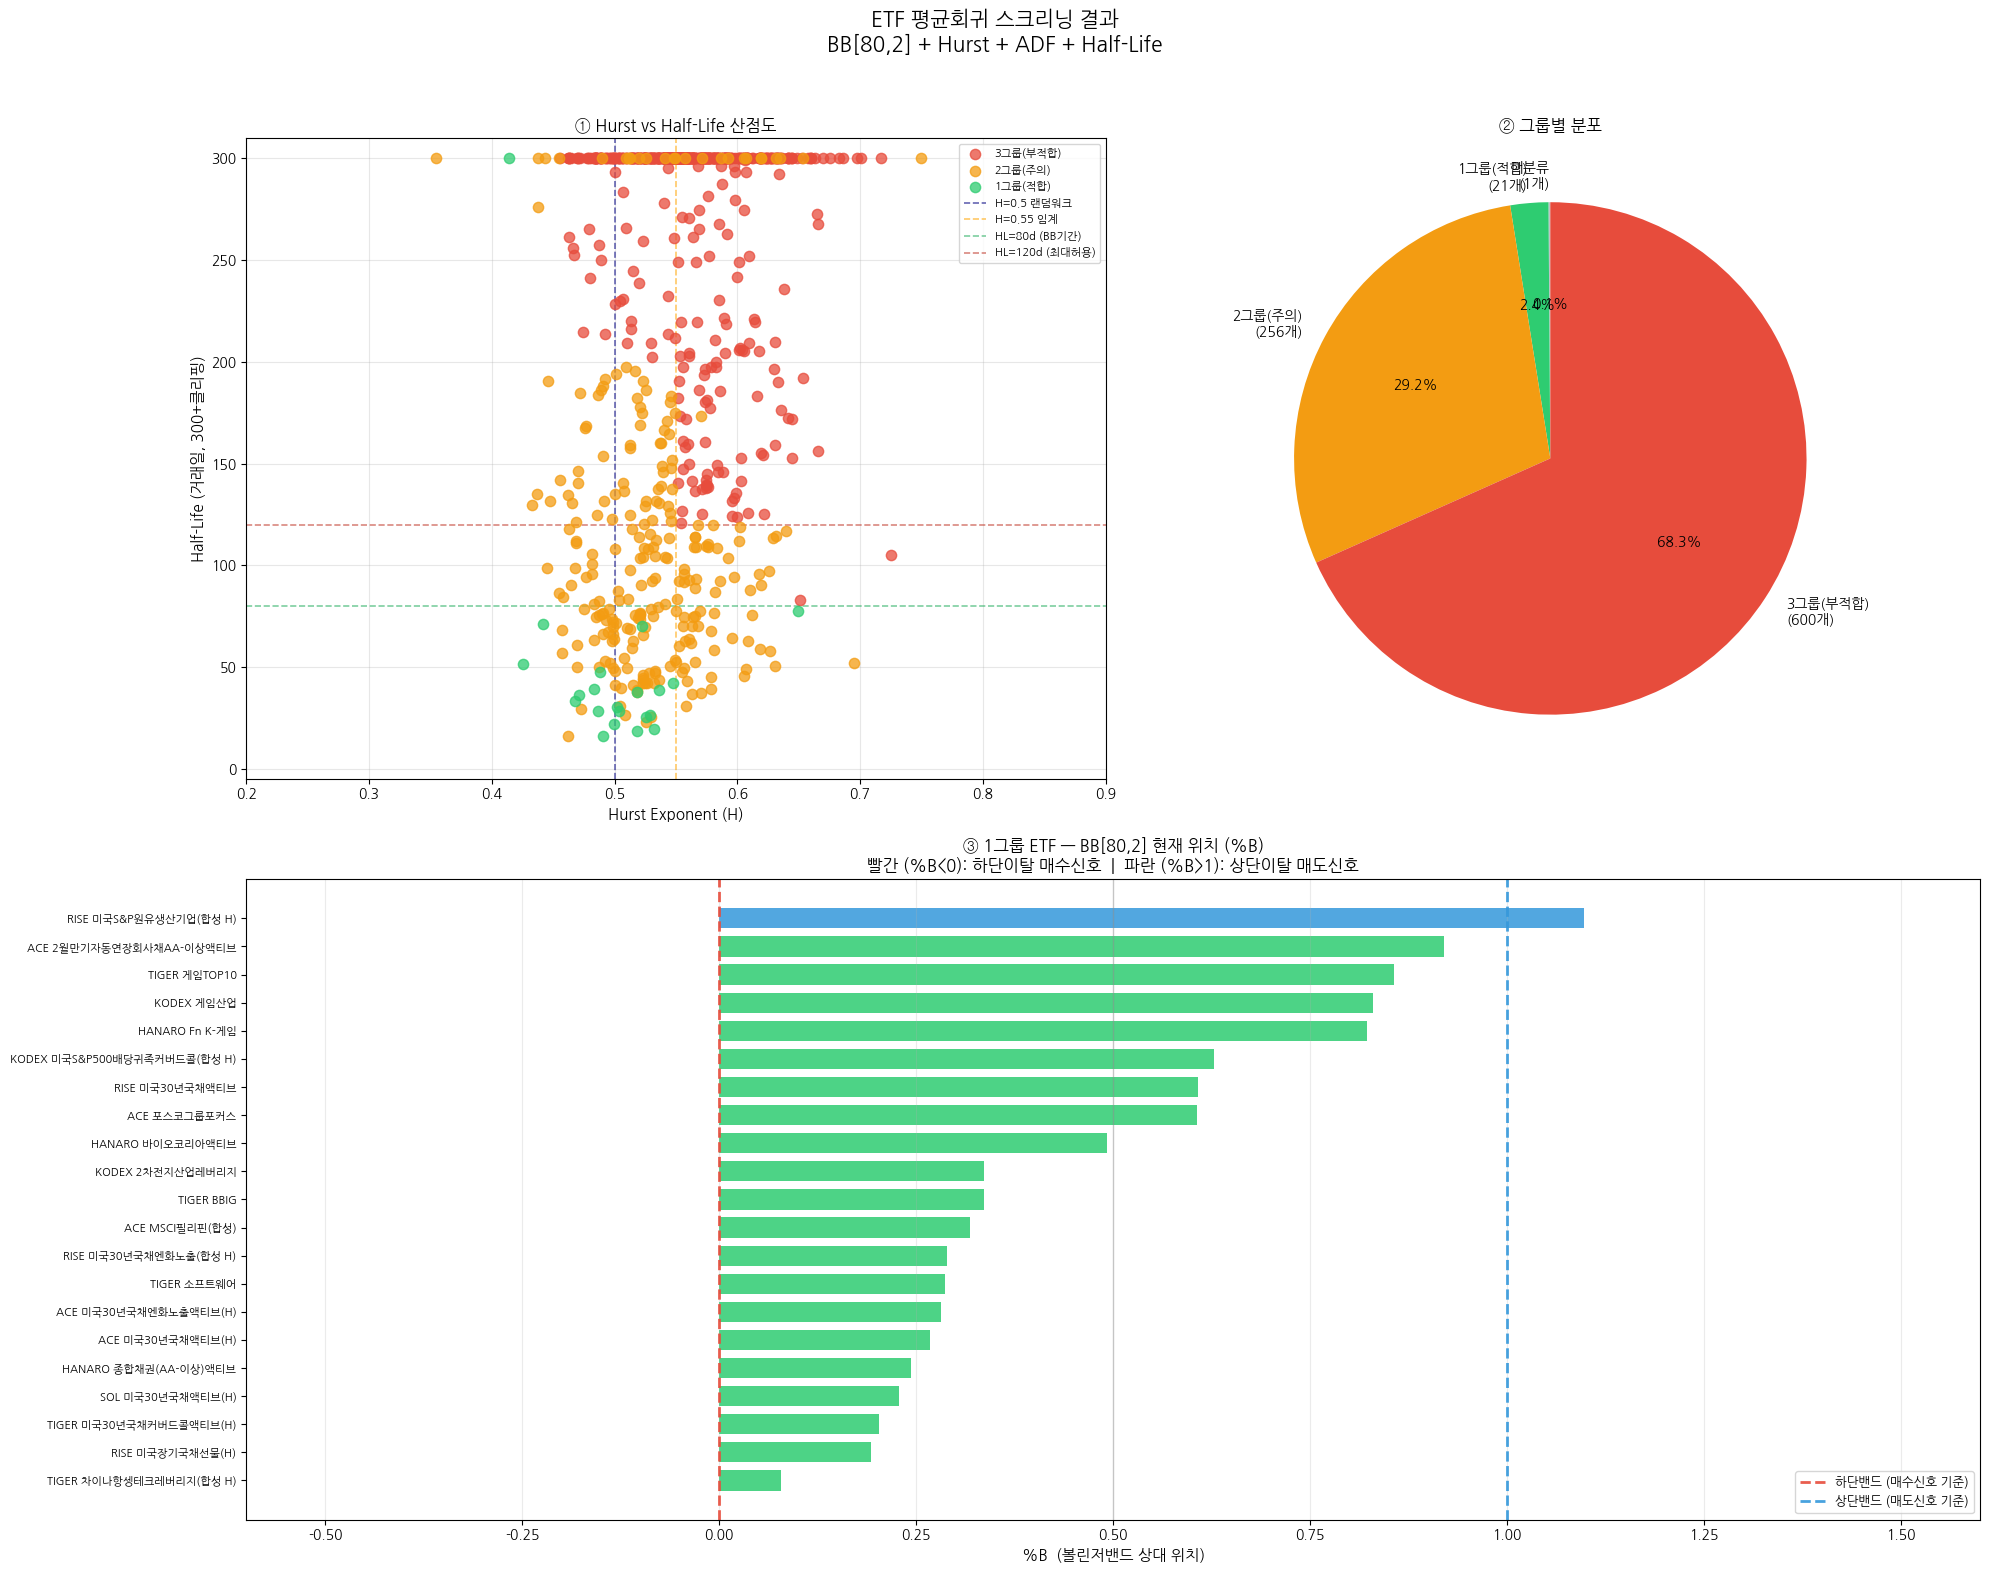

📊 차트 저장: etf_screening_result.png
💾 저장: etf_screening_20260316.csv  /  etf_screening_20260316.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
# [셀 3] 스크리닝 실행 및 다운로드
# 빠른 테스트 모드로 실행 (50개)
#result_df = main(mode='quick', quick_n=50)

# 전체 실행을 원하시면 위 줄을 지우고 아래 줄을 쓰세요.
result_df = main(mode='full')

import datetime, glob
today = datetime.date.today().strftime('%Y%m%d')
for f in glob.glob(f'etf_screening_{today}*'):
    files.download(f)